In [1]:
# Import required libraries
import scanpy as sc
import numpy as np
import pandas as pd

In [2]:
sc.__version__

/tmp/ipykernel_556806/4147423214.py:1: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  sc.__version__


'1.12.1'

# Count Matrix

In [3]:
# Set the file path for the dataset
file_path = "../data/training_cells.h5ad"

In [4]:
# Load data into an AnnData object and print its summary
adata = sc.read_h5ad(file_path)
print(adata)

AnnData object with n_obs × n_vars = 17882 × 19226
    obs: 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'sgrna_id', 'sgrna_symbol', 'channel'
    var: 'features'


In [5]:
# Inspect the main sparse data matrix
print(adata.X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 88576330 stored elements and shape (17882, 19226)>
  Coords	Values
  (0, 7)	2.0
  (0, 16)	1.0
  (0, 25)	1.0
  (0, 27)	1.0
  (0, 39)	1.0
  (0, 49)	1.0
  (0, 51)	1.0
  (0, 55)	1.0
  (0, 56)	3.0
  (0, 57)	1.0
  (0, 64)	1.0
  (0, 66)	1.0
  (0, 68)	1.0
  (0, 72)	1.0
  (0, 77)	2.0
  (0, 88)	1.0
  (0, 90)	1.0
  (0, 92)	1.0
  (0, 97)	1.0
  (0, 111)	2.0
  (0, 112)	1.0
  (0, 114)	1.0
  (0, 117)	1.0
  (0, 120)	1.0
  (0, 125)	1.0
  :	:
  (17881, 19119)	1.0
  (17881, 19127)	1.0
  (17881, 19145)	2.0
  (17881, 19159)	2.0
  (17881, 19163)	1.0
  (17881, 19164)	1.0
  (17881, 19165)	2.0
  (17881, 19166)	1.0
  (17881, 19167)	3.0
  (17881, 19170)	1.0
  (17881, 19172)	1.0
  (17881, 19183)	2.0
  (17881, 19184)	1.0
  (17881, 19200)	1.0
  (17881, 19205)	2.0
  (17881, 19210)	4.0
  (17881, 19211)	2.0
  (17881, 19214)	1.0
  (17881, 19216)	1.0
  (17881, 19217)	3.0
  (17881, 19220)	2.0
  (17881, 19222)	1.0
  (17881, 19223)	2.0
  (17881, 19224)	1.0
  (178

In [6]:
# Preview the first few rows of observation metadata
adata.obs.head()

,nCount_RNA,nFeature_RNA,percent.mt,sgrna_id,sgrna_symbol,channel
AAACCAAAGACGCGAA_ch_1,16395.0,4191,4.306191,INSIG1_3,INSIG1,ch_1
AAACCAAAGCAAATGA_ch_1,12000.0,3631,3.133333,FLNA_2,FLNA,ch_1
AAACCAAAGCAGTCTA_ch_1,55050.0,7061,5.193460,EIF3H_2,EIF3H,ch_1
AAACCAAAGGGCATAG_ch_1,19586.0,5010,6.494435,DZIP3_4,DZIP3,ch_1
AAACCATTCCAATCGA_ch_1,18744.0,4697,4.604140,non-targeting_25,non-targeting,ch_1


In [7]:
# Summarize statistics for observation metadata
adata.obs.describe()

,nCount_RNA,nFeature_RNA,percent.mt
count,17882.000000,17882.000000,17882.000000
mean,21560.050498,4953.379376,5.060519
std,7191.467986,870.723338,1.231257
min,3727.000000,1701.000000,0.000000
25%,16679.000000,4404.000000,4.354134
50%,20710.000000,4980.000000,5.014563
75%,25696.000000,5547.000000,5.709571
max,73785.000000,8051.000000,10.663118


In [8]:
# Count unique values in selected metadata columns
adata.obs[["sgrna_id", "sgrna_symbol","channel"]].nunique()

sgrna_id        339
sgrna_symbol     81
channel           4
dtype: int64

In [9]:
# Calculate the frequency of each sgRNA symbol
adata.obs.sgrna_symbol.value_counts()

sgrna_symbol
non-targeting    1026
MAPK1             447
KDM5C             428
FLNA              415
HDAC4             410
                 ... 
USP22              57
LRPPRC             42
NDUFA2             35
EIF3H              31
ALDOA              31
Name: count, Length: 81, dtype: int64

In [10]:
# Preview the first few rows of variable metadata
adata.var.head()

,features
A1BG,A1BG
A1CF,A1CF
A2M,A2M
A2ML1,A2ML1
A3GALT2,A3GALT2


In [11]:
# Convert the sparse matrix to a dense numpy array
dense_matrix = adata.X.toarray()
print(dense_matrix)

[[0. 0. 0. ... 1. 1. 0.]
 [2. 0. 0. ... 0. 0. 0.]
 [3. 0. 0. ... 3. 2. 2.]
 ...
 [2. 0. 0. ... 0. 0. 1.]
 [0. 0. 0. ... 4. 0. 1.]
 [3. 0. 0. ... 2. 1. 1.]]


In [12]:
# Check the dimensions of the dense matrix
dense_matrix.shape

(17882, 19226)

In [13]:
adata.to_df()

,A1BG,A1CF,A2M,A2ML1,A3GALT2,A4GALT,A4GNT,AAAS,AACS,AADAC,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
AAACCAAAGACGCGAA_ch_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,...,2.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
AAACCAAAGCAAATGA_ch_1,2.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,...,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
AAACCAAAGCAGTCTA_ch_1,3.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,...,1.0,5.0,1.0,1.0,1.0,1.0,1.0,3.0,2.0,2.0
AAACCAAAGGGCATAG_ch_1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,2.0,1.0,0.0
AAACCATTCCAATCGA_ch_1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GTTGTCCGTCCAGTGA_ch_4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,3.0,1.0,0.0,0.0,3.0,0.0,0.0,2.0,0.0,0.0
GTTGTCCGTGGGTTTG_ch_4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
GTTGTCTTCCCCAACC_ch_4,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
GTTGTCTTCCCTTCTC_ch_4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,0.0,0.0,...,3.0,3.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,1.0


# QC metrics

In [14]:
sc.pp.calculate_qc_metrics(adata, inplace=True)

In [15]:
adata

AnnData object with n_obs × n_vars = 17882 × 19226
    obs: 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'sgrna_id', 'sgrna_symbol', 'channel', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'features', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

In [16]:
adata.obs.head()

,nCount_RNA,nFeature_RNA,percent.mt,sgrna_id,sgrna_symbol,channel,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes
AAACCAAAGACGCGAA_ch_1,16395.0,4191,4.306191,INSIG1_3,INSIG1,ch_1,4191,8.340933,16395.0,9.704793,26.471485,36.980787,48.142726,61.939616
AAACCAAAGCAAATGA_ch_1,12000.0,3631,3.133333,FLNA_2,FLNA,ch_1,3631,8.197539,12000.0,9.392745,24.500000,34.558333,45.475000,60.308333
AAACCAAAGCAGTCTA_ch_1,55050.0,7061,5.193460,EIF3H_2,EIF3H,ch_1,7061,8.862484,55050.0,10.916015,24.681199,35.227975,45.762035,58.922797
AAACCAAAGGGCATAG_ch_1,19586.0,5010,6.494435,DZIP3_4,DZIP3,ch_1,5010,8.519391,19586.0,9.882621,24.083529,33.891555,43.990606,57.168386
AAACCATTCCAATCGA_ch_1,18744.0,4697,4.604140,non-targeting_25,non-targeting,ch_1,4697,8.454892,18744.0,9.838682,24.983995,36.182245,47.119078,60.349979


In [17]:
adata.var.head()

,features,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
A1BG,A1BG,10599,1.021362,0.703772,40.728106,18264.0,9.812742
A1CF,A1CF,720,0.046080,0.045050,95.973605,824.0,6.715383
A2M,A2M,20,0.001118,0.001118,99.888156,20.0,3.044522
A2ML1,A2ML1,13,0.000727,0.000727,99.927301,13.0,2.639057
A3GALT2,A3GALT2,31,0.001790,0.001788,99.826641,32.0,3.496508


In [18]:
import matplotlib.pyplot as plt

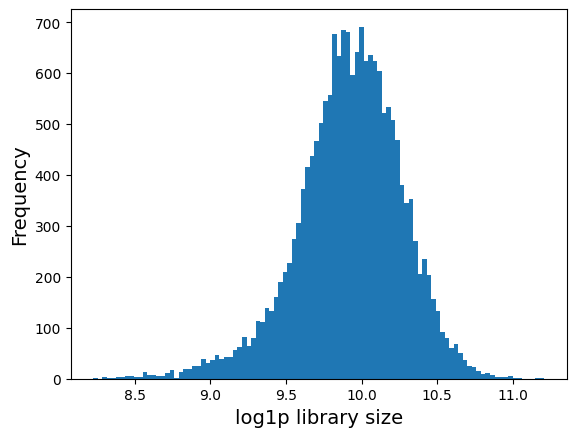

In [19]:
plt.hist(adata.obs['log1p_total_counts'], 100);
plt.xlabel('log1p library size', fontsize = 14)
plt.ylabel('Frequency', fontsize = 14)
plt.show()

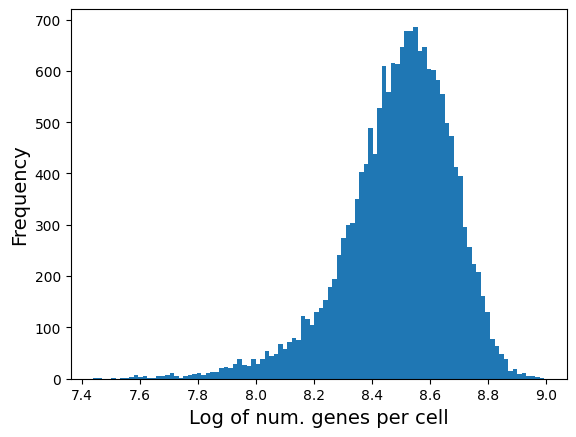

In [20]:
plt.hist(adata.obs['log1p_n_genes_by_counts'], bins = 100);
plt.xlabel('Log of num. genes per cell', fontsize = 14)
plt.ylabel('Frequency', fontsize = 14)
plt.show()

Text(0.5, 1.0, 'Correlation = 0.972')

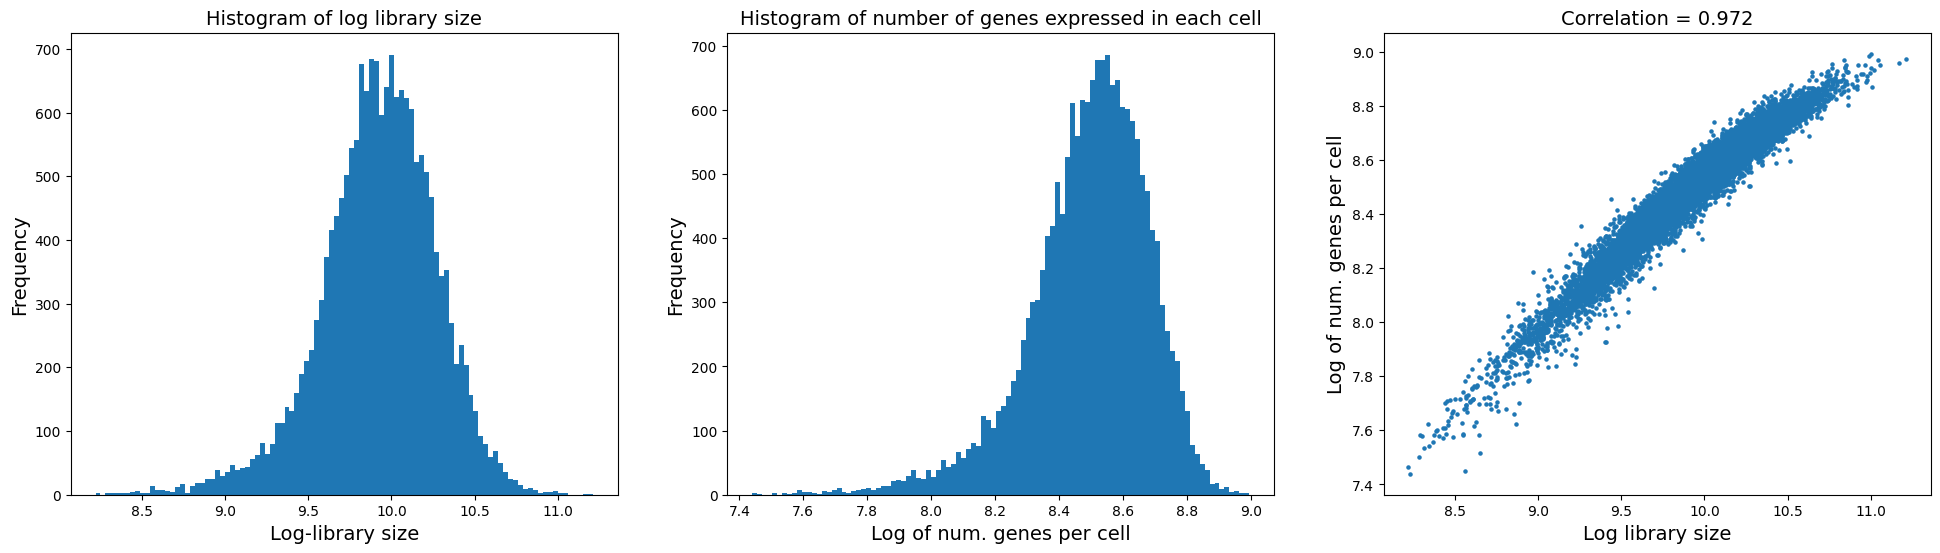

In [21]:
fig = plt.figure(figsize = (8*3, 6*1))
ax = fig.add_subplot(1, 3, 1)
ax.hist(adata.obs['log1p_total_counts'], bins = 100);
ax.set_xlabel('Log-library size', fontsize = 14)
ax.set_ylabel('Frequency', fontsize = 14)
ax.set_title('Histogram of log library size', fontsize = 14)

ax = fig.add_subplot(1, 3, 2)
ax.hist(adata.obs['log1p_n_genes_by_counts'], bins = 100);
ax.set_xlabel('Log of num. genes per cell', fontsize = 14)
ax.set_ylabel('Frequency', fontsize = 14)
ax.set_title('Histogram of number of genes expressed in each cell', fontsize = 14)

ax = fig.add_subplot(1, 3, 3)
x = adata.obs['log1p_total_counts']
y = adata.obs['log1p_n_genes_by_counts']
ax.scatter(x, y, s = 5);
ax.set_ylabel('Log of num. genes per cell', fontsize = 14)
ax.set_xlabel('Log library size', fontsize = 14)
corr_coef = np.corrcoef(x, y)[0, 1]
ax.set_title('Correlation = ' + str(round(corr_coef, 3)), fontsize = 14)

In [22]:
adata.var['mt'] = adata.var_names.str.startswith('MT-')

In [23]:
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

In [24]:
print(adata.obs.columns)

Index(['nCount_RNA', 'nFeature_RNA', 'percent.mt', 'sgrna_id', 'sgrna_symbol',
       'channel', 'n_genes_by_counts', 'log1p_n_genes_by_counts',
       'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes', 'total_counts_mt', 'pct_counts_mt'],
      dtype='str')


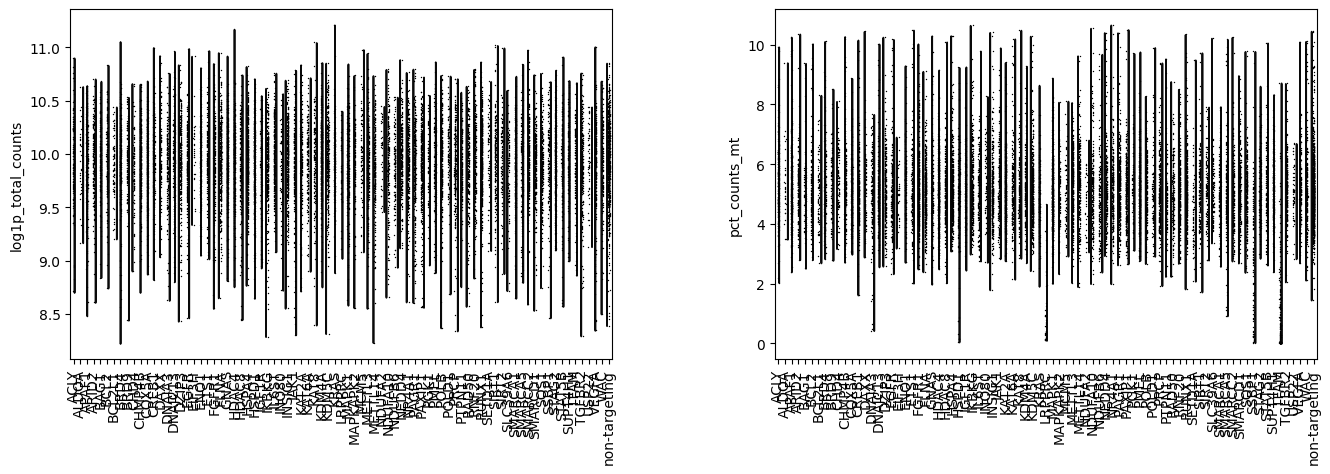

In [25]:
sc.pl.violin(adata, ['log1p_total_counts', 'pct_counts_mt'], groupby='sgrna_symbol', rotation=90)

Text(0, 0.5, '% MT-content')

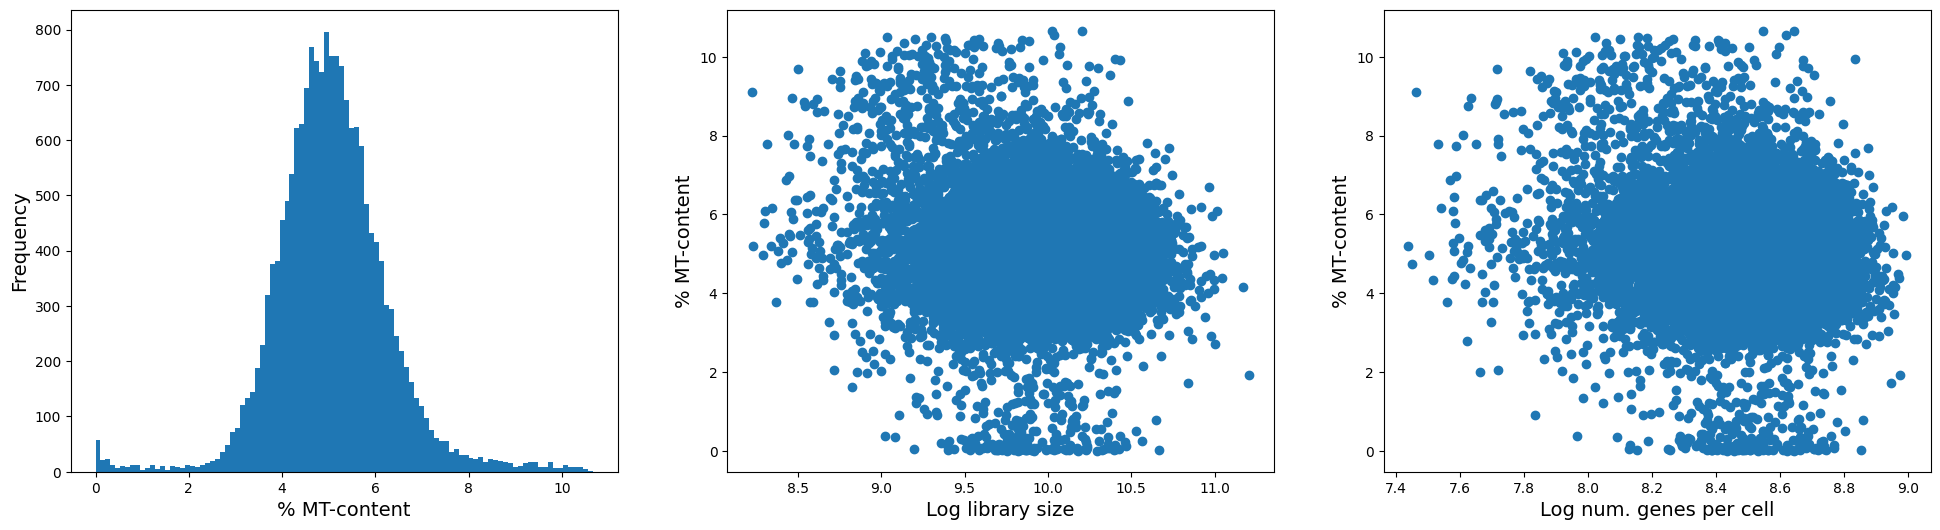

In [26]:
fig = plt.figure(figsize = (8*3, 6*1))
ax = fig.add_subplot(1, 3, 1)
ax.hist(adata.obs['pct_counts_mt'], 100);
ax.set_xlabel('% MT-content', fontsize = 14)
ax.set_ylabel('Frequency', fontsize = 14)

ax = fig.add_subplot(1, 3, 2)
ax.scatter(adata.obs['log1p_total_counts'], adata.obs['pct_counts_mt']);
ax.set_xlabel('Log library size', fontsize = 14)
ax.set_ylabel('% MT-content', fontsize = 14)

ax = fig.add_subplot(1, 3, 3)
ax.scatter(adata.obs['log1p_n_genes_by_counts'], adata.obs['pct_counts_mt']);
ax.set_xlabel('Log num. genes per cell', fontsize = 14)
ax.set_ylabel('% MT-content', fontsize = 14)

In [27]:
adata[adata.obs['pct_counts_mt'] >= 15, :].shape

(0, 19226)

(0.0, 1000.0)

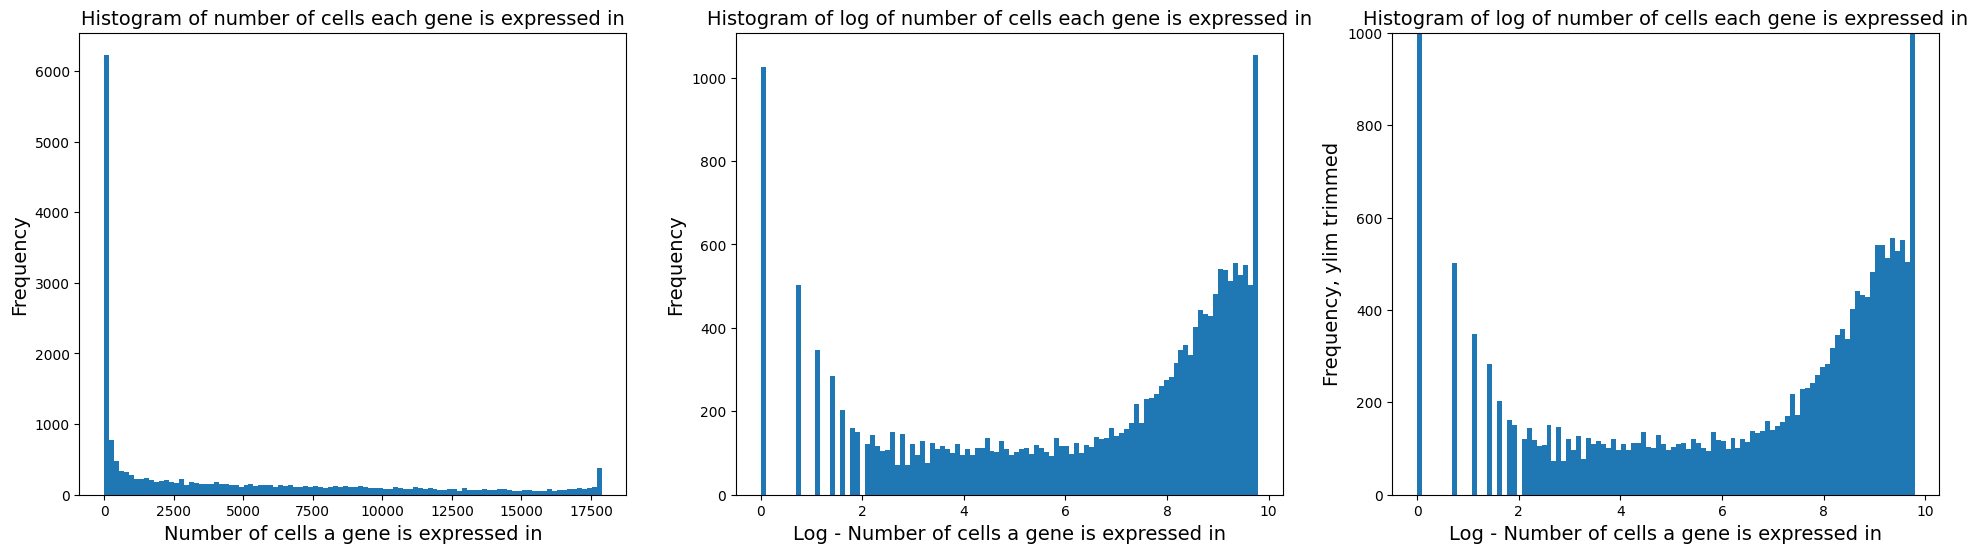

In [28]:
fig = plt.figure(figsize = (8*3, 6*1))
ax = fig.add_subplot(1, 3, 1)
ax.hist(adata.var['n_cells_by_counts'], bins = 100);
ax.set_xlabel('Number of cells a gene is expressed in', fontsize = 14)
ax.set_ylabel('Frequency', fontsize = 14)
ax.set_title('Histogram of number of cells each gene is expressed in', fontsize = 14)

ax = fig.add_subplot(1, 3, 2)
ax.hist(np.log(adata.var['n_cells_by_counts'] + 1), bins = 100);
ax.set_xlabel('Log - Number of cells a gene is expressed in', fontsize = 14)
ax.set_ylabel('Frequency', fontsize = 14)
ax.set_title('Histogram of log of number of cells each gene is expressed in', fontsize = 14)

ax = fig.add_subplot(1, 3, 3)
ax.hist(np.log(adata.var['n_cells_by_counts'] + 1), bins = 100);
ax.set_xlabel('Log - Number of cells a gene is expressed in', fontsize = 14)
ax.set_ylabel('Frequency, ylim trimmed', fontsize = 14)
ax.set_title('Histogram of log of number of cells each gene is expressed in', fontsize = 14)
ax.set_ylim([0, 1000])

In [33]:
submission = pd.read_csv("../data/sample_submission.csv")

In [35]:
submission.shape

(120, 5128)

In [36]:
training = pd.read_csv("../data/training_data_ground_truth_table.csv")
training

,pert_id,A1BG,A1CF,AADAC,AAK1,AARS1,AASS,ABCA1,ABCA12,ABCA5,...,w_ZPBP,w_ZRANB3,w_ZSCAN18,w_ZSCAN31,w_ZSWIM5,w_ZSWIM6,w_ZSWIM7,w_ZWINT,w_ZYX,baseline_wmae
0,ACLY,-0.162420,-0.003694,0.007704,-0.065038,-0.022033,-0.002591,-0.019053,0.012141,-0.012702,...,0.005787,3.673932,0.241709,0.005787,0.023946,0.450036,1.130375,0.005787,2.279422,0.171164
1,ALDOA,0.153383,0.018165,0.001091,-0.001647,-0.079765,-0.002591,0.062238,-0.018650,-0.038159,...,0.010308,2.072907,1.071005,0.868602,0.403595,0.015927,0.056200,2.120163,1.548899,0.159152
2,APAF1,-0.006948,0.004917,-0.002335,0.026446,-0.005120,0.000229,-0.019583,0.007200,0.037674,...,0.039448,0.039448,0.039448,0.039448,0.039448,0.039448,0.039448,0.039448,0.039448,0.107923
3,ARID2,0.043123,-0.007021,0.009316,0.001984,-0.050810,0.007644,-0.013434,-0.002272,0.023748,...,0.015171,0.103470,0.015171,0.015171,0.015171,7.626104,7.328505,2.750918,1.421091,0.095729
4,BAG1,-0.065040,0.009065,0.036724,0.019140,0.081988,0.000408,-0.012373,-0.015974,0.031339,...,0.024883,2.457045,0.024883,0.024883,4.941543,0.411202,0.024883,0.967044,0.267855,0.112668
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,TFAM,0.081642,0.015370,0.018305,-0.077243,0.202509,0.002409,-0.027744,-0.007740,0.010258,...,0.006773,2.866907,0.006773,0.124119,0.980996,1.324769,0.520562,1.030691,0.602567,0.549520
76,TGFBR2,0.063823,-0.010243,0.013749,0.012263,-0.014192,0.003029,0.024227,0.005934,0.007428,...,0.009006,0.009006,0.009006,0.009006,0.009006,1.981879,0.009006,0.009006,0.011622,0.153998
77,USP22,-0.030977,0.019077,0.030058,-0.155155,-0.062633,-0.002591,-0.050061,0.022780,-0.004612,...,0.023633,0.719047,0.023633,0.023633,0.023633,8.077015,0.526186,1.084298,0.245816,0.098115
78,VEGFA,0.024427,-0.016633,0.003278,-0.023062,0.015200,0.001399,-0.002125,-0.001614,-0.013833,...,0.047116,0.047116,0.047116,6.395967,0.172481,0.047116,0.047116,0.047116,0.907399,0.048473


In [37]:
training.shape

(80, 10256)

In [38]:
adata.obs.sgrna_symbol.unique()

['INSIG1', 'FLNA', 'EIF3H', 'DZIP3', 'non-targeting', ..., 'ALDOA', 'NDUFB6', 'BCL2L1', 'NDUFA2', 'USP22']
Length: 81
Categories (81, str): ['ACLY', 'ALDOA', 'APAF1', 'ARID2', ..., 'USP22', 'VEGFA', 'WAC', 'non-targeting']

In [39]:
sum(~training.columns.str.startswith(('w_', 'baseline_wmae', "pert_id")))

np.int64(5127)

> We start from UMI counts of 19,226 genes. The gene list is defined by Gencode v.46.
Raw counts are first log-normalized:
> * Divide the UMI counts in each cell by the total UMI count in that cell
> * Multiply by 10,000
> * Log-transform with log1p (log(x + 1)); logarithm base = 2.
> 
> Normalization is performed on all 19,226 genes to facilitate compatibility with other pre-processed datasets. The normalized data are then subset to the 5,127 genes relevant for the challenge. Finally, expression values for each gene are averaged per perturbation. We use a simple arithmetic mean, disregarding batch information.



In [40]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata, base=2)

In [41]:
target_genes = list(submission.columns)[1:]
adata_target = adata[:, adata.var_names.isin(target_genes)].copy()
adata_target

AnnData object with n_obs × n_vars = 17882 × 5127
    obs: 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'sgrna_id', 'sgrna_symbol', 'channel', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'pct_counts_mt'
    var: 'features', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'mt'
    uns: 'sgrna_symbol_colors', 'log1p'

In [42]:
adata_target.to_df()

,A1BG,A1CF,AADAC,AAK1,AARS1,AASS,ABCA1,ABCA12,ABCA5,ABCB5,...,ZP3,ZPBP,ZRANB3,ZSCAN18,ZSCAN31,ZSWIM5,ZSWIM6,ZSWIM7,ZWINT,ZYX
AAACCAAAGACGCGAA_ch_1,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,...,1.150484,0.0,0.687009,0.0,0.000000,0.0,0.687009,1.150484,0.687009,0.687009
AAACCAAAGCAAATGA_ch_1,1.415037,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,...,0.000000,0.0,0.000000,0.0,0.000000,0.0,2.369234,0.874469,0.000000,0.000000
AAACCAAAGCAGTCTA_ch_1,0.627569,0.0,0.0,0.627569,0.447110,0.0,0.000000,0.0,0.000000,0.0,...,0.240806,0.0,1.397736,0.0,0.000000,0.0,0.787944,0.627569,0.932262,0.627569
AAACCAAAGGGCATAG_ch_1,0.000000,0.0,0.0,1.340110,0.595092,0.0,1.605151,0.0,0.000000,0.0,...,1.015168,0.0,1.340110,0.0,0.000000,0.0,1.340110,0.000000,0.595092,1.015168
AAACCATTCCAATCGA_ch_1,0.616832,0.0,0.0,0.616832,1.648013,0.0,0.000000,0.0,0.000000,0.0,...,0.000000,0.0,0.000000,0.0,0.616832,0.0,2.070741,0.616832,0.000000,0.616832
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GTTGTCCGTCCAGTGA_ch_4,0.556567,0.0,0.0,0.556567,0.556567,0.0,0.000000,0.0,0.556567,0.0,...,0.000000,0.0,1.270407,0.0,0.000000,0.0,0.000000,0.556567,0.556567,0.957195
GTTGTCCGTGGGTTTG_ch_4,0.000000,0.0,0.0,0.000000,1.718389,0.0,0.000000,0.0,0.000000,0.0,...,0.653218,0.0,0.000000,0.0,0.000000,0.0,1.949856,1.101209,0.000000,0.000000
GTTGTCTTCCCCAACC_ch_4,1.542124,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.0,...,0.967991,0.0,0.000000,0.0,0.000000,0.0,0.967991,0.967991,0.000000,0.000000
GTTGTCTTCCCTTCTC_ch_4,0.000000,0.0,0.0,0.741242,1.421714,0.0,0.417712,0.0,0.000000,0.0,...,0.417712,0.0,0.417712,0.0,0.000000,0.0,1.005343,0.741242,1.005343,1.228498


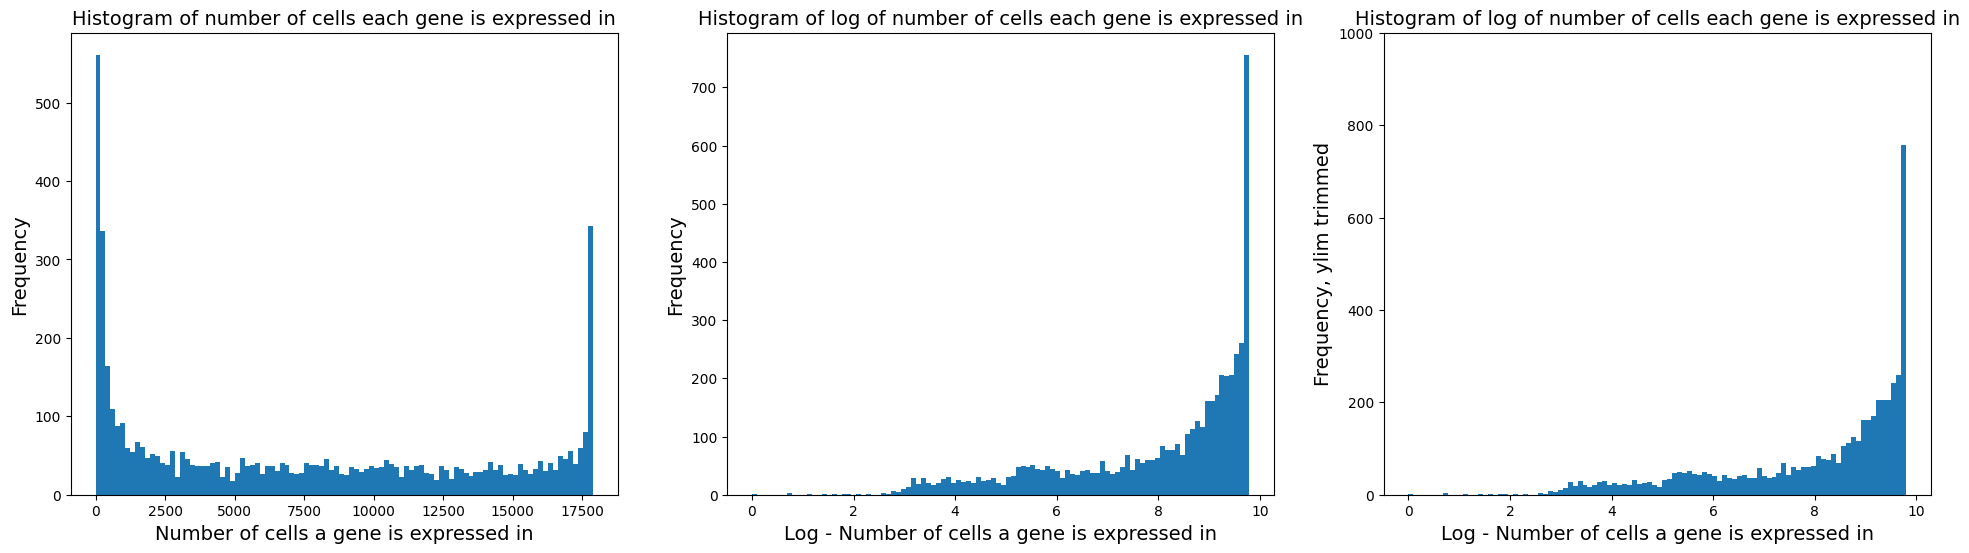

In [44]:
fig = plt.figure(figsize = (8*3, 6*1))
ax = fig.add_subplot(1, 3, 1)
ax.hist(adata_target.var['n_cells_by_counts'], bins = 100);
ax.set_xlabel('Number of cells a gene is expressed in', fontsize = 14)
ax.set_ylabel('Frequency', fontsize = 14)
ax.set_title('Histogram of number of cells each gene is expressed in', fontsize = 14)

ax = fig.add_subplot(1, 3, 2)
ax.hist(np.log(adata_target.var['n_cells_by_counts'] + 1), bins = 100);
ax.set_xlabel('Log - Number of cells a gene is expressed in', fontsize = 14)
ax.set_ylabel('Frequency', fontsize = 14)
ax.set_title('Histogram of log of number of cells each gene is expressed in', fontsize = 14)

ax = fig.add_subplot(1, 3, 3)
ax.hist(np.log(adata_target.var['n_cells_by_counts'] + 1), bins = 100);
ax.set_xlabel('Log - Number of cells a gene is expressed in', fontsize = 14)
ax.set_ylabel('Frequency, ylim trimmed', fontsize = 14)
ax.set_title('Histogram of log of number of cells each gene is expressed in', fontsize = 14)
ax.set_ylim([0, 1000])
plt.show()